In [1]:
import numpy as np
import matplotlib.pyplot as plt


import sys, os
sys.path.append(os.path.abspath("../src"))

from bond import price_coupon_bond, duration_coupon_bond, convexity_coupon_bond


Text(0.5, 1.0, 'Bond Price vs Yield')

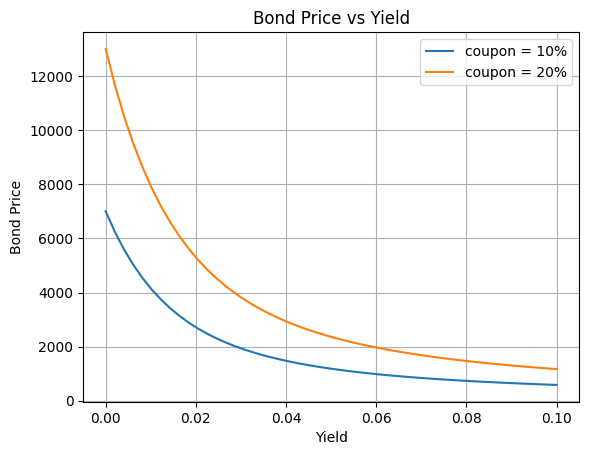

In [14]:
r_grid = np.linspace(0.0, 0.1, 50)
face_value = 1000
coupon_rate = 0.03
periods = 200 
dt = 0.5 
compounding = 'continuous'
prices1 = [price_coupon_bond(face_value, coupon_rate, periods, r, dt, compounding) for r in r_grid]
prices2 = [price_coupon_bond(face_value, coupon_rate*2, periods, r, dt, compounding) for r in r_grid]


plt.plot(r_grid, prices1, label='coupon = 10%')
plt.plot(r_grid, prices2, label='coupon = 20%')
plt.xlabel("Yield")
plt.ylabel("Bond Price")
plt.legend()
plt.grid()
plt.title("Bond Price vs Yield")

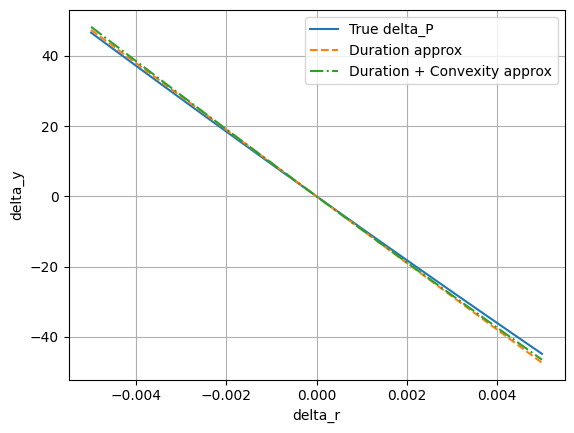

In [17]:
delta_r = np.linspace(-0.005, 0.005, 100)

r = 0.10
face_value = 1000
coupon_rate = 0.10
periods = 20
dt = 0.5
compounding = 'continuous'
prices1 = [price_coupon_bond(face_value, coupon_rate, periods, r, dt, compounding) for r in r_grid]
prices2 = [price_coupon_bond(face_value, coupon_rate*2, periods, r, dt, compounding) for r in r_grid]

price0 = price_coupon_bond(face_value, coupon_rate, periods, r, dt, compounding)
true = [price_coupon_bond(face_value, coupon_rate, periods, r+dr, dt, compounding) - price0 for dr in delta_r]

duration = duration_coupon_bond(face_value, coupon_rate, periods, r, dt, compounding)
duration = duration / (1+r) # modified duration
approx1 = [-duration * price0 * dr for dr in delta_r]

convexity = convexity_coupon_bond(face_value, coupon_rate, periods, r, dt, delta_r=1e-4, compounding=compounding)
approx2 = [-duration * price0 * dr + 0.5 * convexity * price0 * dr**2 for dr in delta_r]

plt.plot(delta_r, true, label="True delta_P")
plt.plot(delta_r, approx1, "--", label="Duration approx")
plt.plot(delta_r, approx2, "-.", label="Duration + Convexity approx")

plt.xlabel('delta_r')
plt.ylabel('delta_y')
plt.legend()
plt.grid()
plt.show()